In [3]:

import pandas as pd
df = pd.read_csv('patients_clean.csv')

df.head()

,URI,uri_user,created,update_uri_user,updated,model,ui,complete,DATE_SUBMIT,marked,...,animal_environment,victim_environment,bite_site,HEALTHY_ANIMAL_BEHAVIOURS,symptoms,treatment_of_victim,SENDER,FACILITY,new_FACILITY,sender_jobtitle
0,uuid:0c773118-979b-4480-9187-2d82c76c99f6,anonymousUser,2019-08-01 12:34:25.578000,NaN,2019-08-01 12:34:25.578000,2019401.0,NaN,1,2019-08-01 12:34:25.572000,2019-08-01 12:34:25.572000,...,from_unknown_place,throwing_things,arms,eating,NaN,"tetanus,immunoglobulin",Immaculate Mosha,FAME HC,FAME Hospital,WORKER
1,uuid:028b2504-d4cb-490e-979a-7d889cdecd75,anonymousUser,2019-08-02 09:39:39.970000,NaN,2019-08-02 09:39:39.970000,2019401.0,NaN,1,2019-08-02 09:39:39.964000,2019-08-02 09:39:39.964000,...,from_unknown_place,no_provocation,legs,NaN,"unprovoked_aggression,excessive_salivation,hyp...","tetanus,wound_washing,antibiotics,immunoglobulin",Peter Rugendo,Manyamanyama Health Center,Manyamanyama Health Center,WORKER
2,uuid:75f9058c-91de-4a5e-8a7c-2a6f6c7fc373,anonymousUser,2019-08-02 20:07:10.623000,NaN,2019-08-02 20:07:10.623000,2019401.0,NaN,1,2019-08-02 20:07:10.616000,2019-08-02 20:07:10.616000,...,from_unknown_place,playing,"head_or_neck,chest",NaN,unprovoked_aggression,"wound_washing,antibiotics,immunoglobulin",Sharifa Abdallah,Tandahimba Hospital,Tandahimba Hospital,WORKER
3,uuid:3a66f865-8668-475e-9b2d-ccd9067115bc,anonymousUser,2019-08-13 11:01:15.837000,NaN,2019-08-13 11:01:15.837000,2019401.0,NaN,1,2019-08-13 11:01:15.830000,2019-08-13 11:01:15.830000,...,lots_of_dogs,running,legs,normal_behaviour,unprovoked_aggression,wound_washing,Mohammed Tilika,Nanyamba Health Center,Nanyamba Health Center,WORKER
4,uuid:842331f0-bc62-463c-ac63-f1c3310b68b8,anonymousUser,2019-08-13 12:37:22.035000,NaN,2019-08-13 12:37:22.035000,2019401.0,NaN,1,2019-08-13 12:37:22.030000,2019-08-13 12:37:22.030000,...,from_unknown_place,no_provocation,"arms,legs",NaN,running_without_reason,"tetanus,wound_washing,antibiotics",Yusuph kaijage,Mahurunga,Mahurunga Health Center,WORKER


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

features = ['REGION', 'animal_alive', 'PEP_AVAILABLE', 'SEX', 'PEP_RECOMMENDED',
            'animal', 'bite_site', 'animal_environment', 'HEALTHY_ANIMAL_BEHAVIOURS', 'symptoms']
target = 'rabies_status'

df.dropna(subset=features + [target], inplace=True)  

encoder = LabelEncoder()
for col in features + [target]:
    df[col] = encoder.fit_transform(df[col])


X = df[features]
y = df[target]


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


svm_model = SVC(kernel='rbf', C=1, gamma = 'scale', random_state=42)
svm_model.fit(x_train, y_train)

y_pred = svm_model.predict(x_test)


accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Model Accuracy: {accuracy:.2f}')
print(report)



Accuracy: 0.4074074074074074
Model Accuracy: 0.41
              precision    recall  f1-score   support

           0       0.48      0.48      0.48        50
           1       0.36      0.87      0.51        30
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        19
           4       0.00      0.00      0.00         1
           5       0.38      0.18      0.24        28

    accuracy                           0.41       135
   macro avg       0.20      0.25      0.21       135
weighted avg       0.34      0.41      0.34       135



c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [7]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf', 'poly']
}

# Perform Grid Search
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Train the best model
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(x_test)

# Evaluate
print(f"Optimized Model Accuracy: {accuracy_score(y_test, y_pred_best):.2f}")
print("Optimized Classification Report:\n", classification_report(y_test, y_pred_best))


Best parameters: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Optimized Model Accuracy: 0.61
Optimized Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.70      0.63        50
           1       0.82      0.90      0.86        30
           2       0.20      0.14      0.17         7
           3       0.83      0.26      0.40        19
           4       0.00      0.00      0.00         1
           5       0.50      0.54      0.52        28

    accuracy                           0.61       135
   macro avg       0.49      0.42      0.43       135
weighted avg       0.63      0.61      0.60       135



c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

    MODEL FROM THE BEST PARAMETERS PROVIDED ABOVE


In [19]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


svm_model = SVC(kernel='rbf', C=100, gamma = 'auto', random_state=42)
svm_model.fit(x_train, y_train)

y_pred = svm_model.predict(x_test)


accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Model Accuracy: {accuracy:.2f}')
print(report)



Accuracy: 0.6148148148148148
Model Accuracy: 0.61
              precision    recall  f1-score   support

           0       0.57      0.70      0.63        50
           1       0.82      0.90      0.86        30
           2       0.20      0.14      0.17         7
           3       0.83      0.26      0.40        19
           4       0.00      0.00      0.00         1
           5       0.50      0.54      0.52        28

    accuracy                           0.61       135
   macro avg       0.49      0.42      0.43       135
weighted avg       0.63      0.61      0.60       135



c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [2]:
import pandas as pd
df = pd.read_csv('patients_clean.csv')
unique_classes = df['rabies_status'].unique()
print("Unique Classes in 'rabies_status':", unique_classes)


Unique Classes in 'rabies_status': ['unknown' 'suspicious_for_rabies' 'sick_not_rabies' 'healthy'
 'suspicious_for_of_rabies' nan 'treatment']


REMOVING THE CLASES [2][3][4] FROM THE LABEL

In [ ]:

# Filter dataset for rabies_status values 0, 1, and 5
df_filtered = df[df['rabies_status'].isin([0, 1, 5])]

# Convert categorical features to numerical using Label Encoding
for col in features:
    df_filtered[col] = LabelEncoder().fit_transform(df_filtered[col])

# Split dataset
X = df_filtered[features]
y = df_filtered[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM model
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


Model Accuracy: 0.73
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.91      0.82        45
           1       0.66      0.72      0.69        32
           5       0.82      0.51      0.63        35

    accuracy                           0.73       112
   macro avg       0.74      0.71      0.71       112
weighted avg       0.74      0.73      0.72       112



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23588\1798185143.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[col] = LabelEncoder().fit_transform(df_filtered[col])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23588\1798185143.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[col] = LabelEncoder().fit_transform(df_filtered[col])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23588\1798185143.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

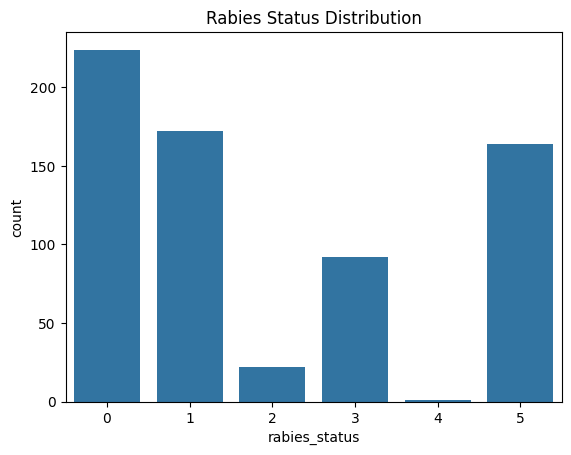

rabies_status
0    224
1    172
5    164
3     92
2     22
4      1
Name: count, dtype: int64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution
sns.countplot(x=df['rabies_status'])
plt.title("Rabies Status Distribution")
plt.show()

# Print value counts
print(df['rabies_status'].value_counts())


In [11]:
# Use One-Hot Encoding for categorical features
X_encoded = pd.get_dummies(df[features], drop_first=True)

# Split again
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train again
svm_model.fit(X_train, y_train)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Model Accuracy: {accuracy:.2f}')
print(report)

Accuracy: 0.4074074074074074
Model Accuracy: 0.41
              precision    recall  f1-score   support

           0       0.48      0.48      0.48        50
           1       0.36      0.87      0.51        30
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        19
           4       0.00      0.00      0.00         1
           5       0.38      0.18      0.24        28

    accuracy                           0.41       135
   macro avg       0.20      0.25      0.21       135
weighted avg       0.34      0.41      0.34       135



c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [12]:
for kernel in ['linear', 'rbf', 'poly', 'sigmoid']:
    model = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Kernel: {kernel} - Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Kernel: linear - Accuracy: 0.54
Kernel: rbf - Accuracy: 0.41
Kernel: poly - Accuracy: 0.47
Kernel: sigmoid - Accuracy: 0.38


In [16]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


svm_model = SVC(kernel='linear', C=1, gamma = 'scale', random_state=42)
svm_model.fit(x_train, y_train)

y_pred = svm_model.predict(x_test)


accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Model Accuracy: {accuracy:.2f}')
print(report)



Accuracy: 0.5407407407407407
Model Accuracy: 0.54
              precision    recall  f1-score   support

           0       0.62      0.80      0.70        50
           1       0.45      0.67      0.54        30
           2       0.00      0.00      0.00         7
           3       1.00      0.11      0.19        19
           4       0.00      0.00      0.00         1
           5       0.46      0.39      0.42        28

    accuracy                           0.54       135
   macro avg       0.42      0.33      0.31       135
weighted avg       0.56      0.54      0.49       135



c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train again
svm_model.fit(X_train, y_train)


SVC(C=1, kernel='linear', random_state=42)